Benchmark : singleset_256bd.xlsx
  行数=252, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 971.4 fs

  [已绘制] singleset  ($\chi'=16$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=2.9028e-02,  均值平均累计误差=1.2243e-02
  [已绘制] multiset_thermo  ($\chi'=16$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=2.4800e-02,  均值平均累计误差=8.8018e-03
  [已绘制] singleset  ($\chi'=64$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=1.0201e-02,  均值平均累计误差=3.7909e-03
  [已绘制] multiset_thermo  ($\chi'=64$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=1.0174e-02,  均值平均累计误差=2.8858e-03
  [已绘制] singleset  ($\chi'=128$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=4.0108e-03,  均值平均累计误差=1.4541e-03


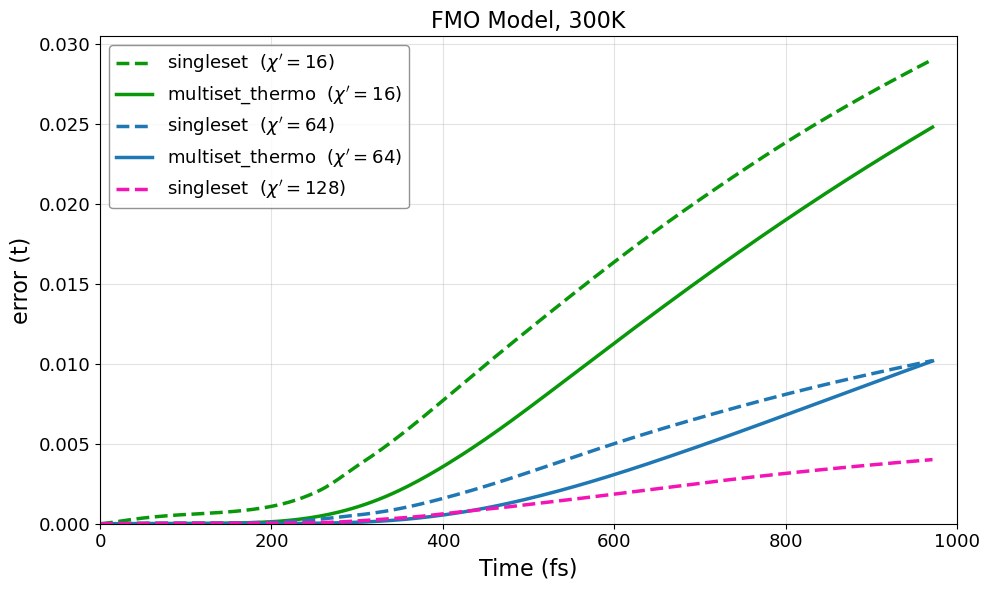

In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_average_cumulative_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算 multiset_thermo64、multiset_thermo16、singleset_64、
    singleset_16、singleset_128 的 average cumulative error 并绘图。
    """

    test_dir = "."
    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    data_files = [
        os.path.join(test_dir, "singleset_16bd.xlsx"),
        os.path.join(test_dir, "multiset_16bd_thermo.xlsx"),
        os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd_thermo.xlsx"),
        os.path.join(test_dir, "singleset_128bd.xlsx"),
    ]

    styles = {
        "singleset_16bd.xlsx": ("singleset  ($\\chi'=16$)", "#08980a", "--", 2.5),
        "multiset_16bd_thermo.xlsx": ("multiset_thermo  ($\\chi'=16$)", "#08980a", "-", 2.5),
        "singleset_64bd.xlsx": ("singleset  ($\\chi'=64$)", "#1f77b4", "--", 2.5),
        "multiset_64bd_thermo.xlsx": ("multiset_thermo  ($\\chi'=64$)", "#1f77b4", "-", 2.5),
        "singleset_128bd.xlsx": ("singleset  ($\\chi'=128$)", "#f414b5", "--", 2.5),
    }

    dt_au = 160
    dt = dt_au * 0.024188843265

    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]
    y_bm = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm = np.arange(len(y_bm)) * dt

    print("Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        df_pred = pd.read_excel(fpath, header=None)
        y_pred = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred = np.arange(len(y_pred)) * dt

        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算平均累计误差：sum_n integral_0^t |P_n - P_ref_n| dt' / (n_col * t)
        abs_err = np.abs(y_pred - y_bm_interp)
        cum_err = np.zeros(len(x_pred), dtype=float)
        if len(x_pred) > 1:
            dt_seg = np.diff(x_pred)
            seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * dt_seg[:, None]
            cumulative_integral = np.cumsum(seg_integral, axis=0)
            cum_err[1:] = np.sum(cumulative_integral, axis=1) / (n_col * x_pred[1:])

        ax.plot(
            x_pred,
            cum_err,
            label=label,
            color=color,
            linestyle=ls,
            linewidth=lw,
        )

        print(f"  [已绘制] {label}")
        print(
            f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
            f"最大平均累计误差={cum_err.max():.4e},  均值平均累计误差={cum_err.mean():.4e}"
        )

    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("error (t)", fontsize=16)
    ax.set_title(
        "FMO Model, 300K",
        fontsize=16,
    )
    ax.set_xlim(left=0, right=1000)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    # plt.savefig("FMO_avg_cumulative_error_vs_256bd.png", dpi=150)
    plt.show()


plot_fmo_average_cumulative_error()


Benchmark : singleset_256bd.xlsx
  行数=252, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 971.4 fs

  [已绘制] singleset  ($\chi'=16$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=2.9028e-02,  均值平均累计误差=1.2243e-02
  [已绘制] multiset_thermo  ($\chi'=16$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=2.4800e-02,  均值平均累计误差=8.8018e-03
  [已绘制] singleset  ($\chi'=64$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=1.0201e-02,  均值平均累计误差=3.7909e-03
  [已绘制] multiset_thermo  ($\chi'=64$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=1.0174e-02,  均值平均累计误差=2.8858e-03
  [已绘制] singleset  ($\chi'=128$)
    时间范围: 0 ~ 971.4 fs,  最大平均累计误差=4.0108e-03,  均值平均累计误差=1.4541e-03


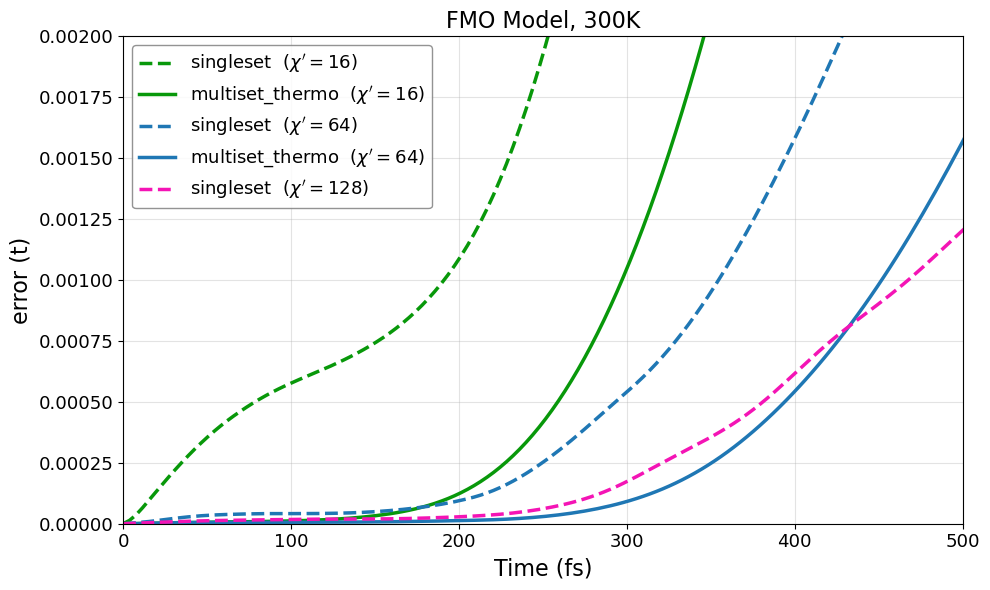

In [12]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_average_cumulative_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算 multiset_thermo64、multiset_thermo16、singleset_64、
    singleset_16、singleset_128 的 average cumulative error 并绘图。
    """

    test_dir = "."
    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    data_files = [
        os.path.join(test_dir, "singleset_16bd.xlsx"),
        os.path.join(test_dir, "multiset_16bd_thermo.xlsx"),
        os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd_thermo.xlsx"),
        os.path.join(test_dir, "singleset_128bd.xlsx"),
    ]

    styles = {
        "singleset_16bd.xlsx": ("singleset  ($\\chi'=16$)", "#08980a", "--", 2.5),
        "multiset_16bd_thermo.xlsx": ("multiset_thermo  ($\\chi'=16$)", "#08980a", "-", 2.5),
        "singleset_64bd.xlsx": ("singleset  ($\\chi'=64$)", "#1f77b4", "--", 2.5),
        "multiset_64bd_thermo.xlsx": ("multiset_thermo  ($\\chi'=64$)", "#1f77b4", "-", 2.5),
        "singleset_128bd.xlsx": ("singleset  ($\\chi'=128$)", "#f414b5", "--", 2.5),
    }

    dt_au = 160
    dt = dt_au * 0.024188843265

    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]
    y_bm = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm = np.arange(len(y_bm)) * dt

    print("Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        df_pred = pd.read_excel(fpath, header=None)
        y_pred = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred = np.arange(len(y_pred)) * dt

        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算平均累计误差：sum_n integral_0^t |P_n - P_ref_n| dt' / (n_col * t)
        abs_err = np.abs(y_pred - y_bm_interp)
        cum_err = np.zeros(len(x_pred), dtype=float)
        if len(x_pred) > 1:
            dt_seg = np.diff(x_pred)
            seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * dt_seg[:, None]
            cumulative_integral = np.cumsum(seg_integral, axis=0)
            cum_err[1:] = np.sum(cumulative_integral, axis=1) / (n_col * x_pred[1:])

        ax.plot(
            x_pred,
            cum_err,
            label=label,
            color=color,
            linestyle=ls,
            linewidth=lw,
        )

        print(f"  [已绘制] {label}")
        print(
            f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
            f"最大平均累计误差={cum_err.max():.4e},  均值平均累计误差={cum_err.mean():.4e}"
        )

    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("error (t)", fontsize=16)
    ax.set_title(
        "FMO Model, 300K",
        fontsize=16,
    )
    ax.set_xlim(left=0, right=500)
    ax.set_ylim(bottom=0,top=0.002)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    # plt.savefig("FMO_avg_cumulative_error_vs_256bd.png", dpi=150)
    plt.show()


plot_fmo_average_cumulative_error()
